In [27]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Load data
train_path = "data/train.csv"
test_path = "data/test.csv"
sample_sub_path = "data/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

In [17]:
target_col = "diagnosed_diabetes"
id_col = "id"

In [18]:
# Split features and target
X = train_df.drop(columns=[target_col])
y = train_df[target_col]
X_test = test_df.copy()

In [19]:
# Detect numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols = [col for col in num_cols if col in X.columns]
cat_cols = [col for col in cat_cols if col in X.columns]

if id_col in num_cols:
    num_cols.remove(id_col)
if id_col in cat_cols:
    cat_cols.remove(id_col)

In [20]:
poly_cols = [
    "age",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "ldl_cholesterol",
    "physical_activity_minutes_per_week"
]

poly_cols = [col for col in poly_cols if col in num_cols]
remaining_num_cols = [col for col in num_cols if col not in poly_cols]

print("Polynomial feature columns:", poly_cols)
print("Remaining numeric columns:", remaining_num_cols)
print("cat_cols:", cat_cols)

Polynomial feature columns: ['age', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'ldl_cholesterol', 'physical_activity_minutes_per_week']
Remaining numeric columns: ['alcohol_consumption_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
cat_cols: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [21]:
X = X[num_cols + cat_cols]
X_test = X_test[num_cols + cat_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [22]:
poly_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

remaining_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("poly_num", poly_numeric_transformer, poly_cols),
        ("num", remaining_numeric_transformer, remaining_num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    verbose_feature_names_out=False
)

In [23]:
# LightGBM baseline model
lgbm_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgbm_model)
])

In [24]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgbm_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Fold AUC scores:", cv_scores)
print("Mean CV AUC:", cv_scores.mean())
print("Std CV AUC:", cv_scores.std())

/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning

Fold AUC scores: [0.72369454 0.72156431 0.72227968 0.72375231 0.7233502 ]
Mean CV AUC: 0.7229282092508538
Std CV AUC: 0.0008631681600652047


In [25]:
# Train on full training data
lgbm_pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('poly_num', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [26]:
# Predict on test data
test_pred_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

# Create submission
submission = sample_sub.copy()
submission.iloc[:, 1] = test_pred_proba

submission.to_csv("submissions/lightgbm_polynomial.csv", index=False)
print("Saved: submissions/lightgbm_polynomial.csv")

/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/var/folders/m_/gq3fgb6x2rs_xpbs_2llxbvc0000gn/T/ipykernel_19409/1179503944.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.52858077 0.66831964 0.7666745  ... 0.51208727 0.6180053  0.59921814]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.iloc[:, 1] = test_pred_proba


Saved: submissions/lightgbm_polynomial.csv


                                              feature  importance
5                  physical_activity_minutes_per_week        2363
35                                      triglycerides         947
26               physical_activity_minutes_per_week^2         562
32                                         heart_rate         307
33                                  cholesterol_total         304
7                                             age bmi         285
0                                                 age         269
28                                         diet_score         264
34                                    hdl_cholesterol         252
4                                     ldl_cholesterol         208
3                                         systolic_bp         201
8                              age waist_to_hip_ratio         181
30                          screen_time_hours_per_day         179
1                                                 bmi         172
10        

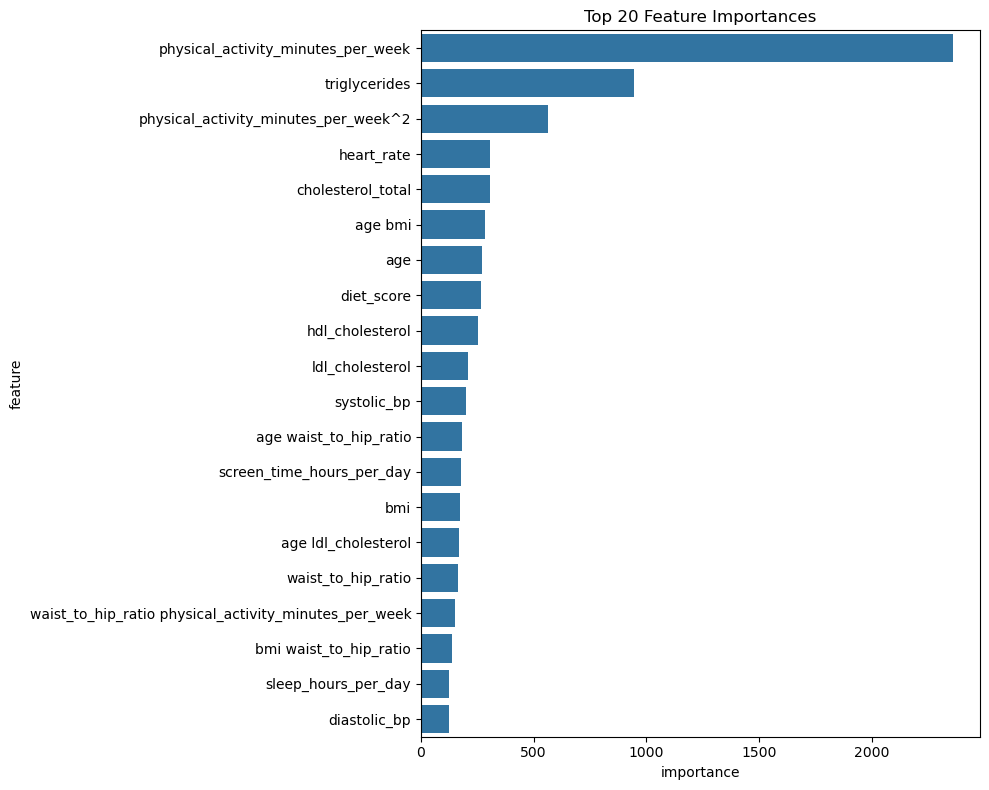

In [28]:
feature_names = lgbm_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = lgbm_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df.head(30))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()